# Notebook 06 - Interpretability

Notebook này thực hiện diễn giải mô hình (Model Interpretability) nhằm xác định các yếu tố ảnh hưởng đến Digital Burnout thông qua mô hình XGBoost. Việc diễn giải bao gồm phân tích toàn cục (Global Interpretability) và phân tích cục bộ (Local Interpretability) bằng thư viện SHAP (SHapley Additive exPlanations).

Kết quả của notebook sẽ hỗ trợ giải thích cơ chế ra quyết định của mô hình và cung cấp bằng chứng cho các kết luận nghiên cứu.

# 0. Set Up

Nhập các thư viện cần thiết, thiết lập cấu hình chung và khai báo các đường dẫn sử dụng trong notebook.

In [1]:
# Thư viện hệ thống

import os
import gc
import time
import random
import warnings

from pathlib import Path

# Thư viện xử lý dữ liệu

import joblib
import numpy as np
import pandas as pd

# Thư viện trực quan hóa

import matplotlib.pyplot as plt
import seaborn as sns

# Thư viện Machine Learning

import shap

# Cấu hình hiển thị

warnings.filterwarnings("ignore")

pd.set_option(

    "display.max_columns",
    None

)

pd.set_option(

    "display.float_format",
    "{:.4f}".format

)

plt.style.use(

    "default"

)

In [2]:
# Thiết lập Random Seed

random_state = 42

random.seed(
    random_state
)

np.random.seed(
    random_state
)

In [3]:
# Thiết lập đường dẫn dự án

project_root = (

    Path.cwd()
    .resolve()
    .parents[1]

)

# Thư mục dữ liệu

data_directory = (

    project_root
    / "data"
    / "processed"
    / "international_dataset"

)

# Thư mục mô hình

model_directory = (

    project_root
    / "models"
    / "international_dataset"

)

# Thư mục Interpretability

interpretability_directory = (

    model_directory
    / "interpretability"

)

interpretability_directory.mkdir(

    parents=True,
    exist_ok=True

)

print(
    f"Đường dẫn dự án: {project_root}"
)

print(
    f"Thư mục dữ liệu: {data_directory}"
)

print(
    f"Thư mục mô hình: {model_directory}"
)

print(
    f"Thư mục Interpretability: {interpretability_directory}"
)

Đường dẫn dự án: D:\DA016
Thư mục dữ liệu: D:\DA016\data\processed\international_dataset
Thư mục mô hình: D:\DA016\models\international_dataset
Thư mục Interpretability: D:\DA016\models\international_dataset\interpretability


In [4]:
# Kiểm tra phần cứng

print(
    f"SHAP Version: {shap.__version__}"
)

print(
    f"CPU Cores: {os.cpu_count()}"
)

SHAP Version: 0.52.0
CPU Cores: 12


# 1. Load Interpretability Model

Tải mô hình XGBoost đã được huấn luyện trong Notebook 05 cùng với tập dữ liệu xác thực. Mô hình này sẽ được sử dụng để thực hiện phân tích Global Interpretability và Local Interpretability bằng SHAP.

## 1.1 Load XGBoost Model

Tải mô hình XGBoost đã được huấn luyện và lưu trữ trong Notebook 05. Mô hình này được lựa chọn để thực hiện diễn giải do hỗ trợ SHAP trực tiếp và có hiệu năng dự đoán cạnh tranh.

In [5]:
# Tải mô hình XGBoost

xgboost_pipeline = joblib.load(
    model_directory
    / "xgboost.joblib"
)

print(
    "Đã tải mô hình XGBoost."
)

Đã tải mô hình XGBoost.


## 1.2 Load Validation Dataset

Tải tập dữ liệu đã được làm sạch và danh sách đặc trưng đã được xác thực từ Notebook 04. Các đặc trưng này sẽ được sử dụng để xây dựng tập dữ liệu phục vụ phân tích SHAP.

In [6]:
# Tải tập Validation Features

X_validation = joblib.load(
    model_directory
    / "X_validation.joblib"
)

print(
    f"Kích thước X_validation: {X_validation.shape}"
)

Kích thước X_validation: (750000, 26)


In [7]:
# Tải tập Validation Labels

y_validation = joblib.load(
    model_directory
    / "y_validation.joblib"
)

print(
    f"Kích thước y_validation: {y_validation.shape}"
)

Kích thước y_validation: (750000,)


In [8]:
display(
    X_validation.head()
)

display(
    y_validation.head()
)

,emotional_exhaustion,stress_level,daily_screen_time,work_satisfaction,doomscrolling_duration,distraction_frequency,sleep_hours,notification_count,physical_activity,deep_work_hours,late_night_device_usage,focus_sessions,app_switch_frequency,smartphone_unlocks,social_media_hours,task_completion_rate,meeting_hours,age,concentration_score,mental_fatigue,sleep_quality,motivation_level,workspace_quality,internet_stability,caffeine_intake,remote_work_days
1815910,7,10,6.1000,7,1.2000,4,7.0000,378,1.8000,3.1000,0,9,123,278,4.3000,93,3.4000,59,7,3,3,6.0000,5,2,5,1
2150771,6,8,7.3000,8,0.8000,101,7.3000,129,1.4000,2.9000,1,6,49,129,4.3000,78,3.5000,42,5,5,5,7.0000,2,3,4,3
2340715,8,10,5.2000,4,3.7000,53,6.5000,32,0.4000,1.9000,0,2,62,293,8.3000,80,4.3000,58,4,7,9,3.0000,7,6,6,5
4808205,4,1,4.9000,2,1.5000,102,7.5000,366,1.1000,2.9000,0,7,74,248,5.0000,60,2.2000,19,2,4,9,10.0000,8,5,5,1
2188076,4,10,6.3000,7,3.5000,55,8.0000,335,1.5000,3.4000,1,2,45,77,1.3000,97,3.5000,18,3,2,7,4.0000,5,7,1,2


1815910    2
2150771    1
2340715    1
4808205    0
2188076    2
Name: burnout_level, dtype: int64

## 1.3 Prepare SHAP Sample

Lấy một tập mẫu đại diện từ tập dữ liệu để thực hiện phân tích SHAP. Việc sử dụng tập mẫu giúp giảm thời gian tính toán trong khi vẫn đảm bảo khả năng diễn giải mô hình.

In [9]:
# Lấy mẫu dữ liệu cho SHAP

shap_sample_size = 1000

X_shap = X_validation.sample(
    n=shap_sample_size,
    random_state=random_state
)

print(
    f"Số lượng mẫu SHAP: {len(X_shap):,}"
)

Số lượng mẫu SHAP: 1,000


# 2. Global Interpretability

## 2.1 Feature Importance

Đánh giá mức độ quan trọng của từng đặc trưng dựa trên mô hình XGBoost. Kết quả giúp xác định những yếu tố có ảnh hưởng lớn nhất đến quá trình dự đoán Digital Burnout.

In [10]:
# Lấy mô hình XGBoost

xgboost_model = (
    xgboost_pipeline
    .named_steps["model"]
)

# Lấy preprocessing

preprocessing = (
    xgboost_pipeline
    .named_steps["preprocessing"]
)

feature_names = (
    preprocessing
    .get_feature_names_out()
)

feature_importance = pd.DataFrame(

    {
        "Feature": feature_names,
        "Importance": xgboost_model.feature_importances_
    }

)

feature_importance = (

    feature_importance

    .sort_values(
        by="Importance",
        ascending=False
    )

    .reset_index(
        drop=True
    )

)

display(
    feature_importance.head(20)
)

feature_importance.to_csv(

    interpretability_directory
    / "feature_importance.csv",
    index=False

)

,Feature,Importance
0,numerical__emotional_exhaustion,0.3311
1,numerical__stress_level,0.1955
2,numerical__work_satisfaction,0.1094
3,numerical__late_night_device_usage,0.0869
4,numerical__daily_screen_time,0.0468
5,numerical__doomscrolling_duration,0.0466
6,numerical__distraction_frequency,0.0309
7,numerical__sleep_hours,0.0258
8,numerical__physical_activity,0.0239
9,numerical__notification_count,0.0180


## 2.2 SHAP Summary Plot

Áp dụng phương pháp SHAP (SHapley Additive exPlanations) nhằm giải thích mức độ đóng góp của từng thuộc tính vào kết quả dự báo của mô hình.

Biểu đồ tổng quan SHAP trực quan hóa đồng thời các yếu tố sau:

- Tầm quan trọng tổng thể của các thuộc tính.
- Tác động tích cực (ảnh hưởng dương) và tiêu cực (ảnh hưởng âm) của thuộc tính.
- Phân phối của các giá trị SHAP.
- Xu hướng hành vi của giá trị thuộc tính trên toàn bộ tập mẫu kiểm định (validation samples).

Sự trực quan hóa này mang lại một góc nhìn giải thích toàn cục (global explanation) toàn diện về mô hình đã được huấn luyện.

In [11]:
# Chuẩn bị dữ liệu cho SHAP

preprocessing = (
    xgboost_pipeline
    .named_steps["preprocessing"]
)

X_shap_processed = preprocessing.transform(
    X_shap
)

feature_names = preprocessing.get_feature_names_out()

X_shap_processed = pd.DataFrame(

    X_shap_processed,
    columns=feature_names,
    index=X_shap.index

)

In [12]:
explainer = shap.TreeExplainer(
    xgboost_model
)

shap_values = explainer(
    X_shap_processed
)

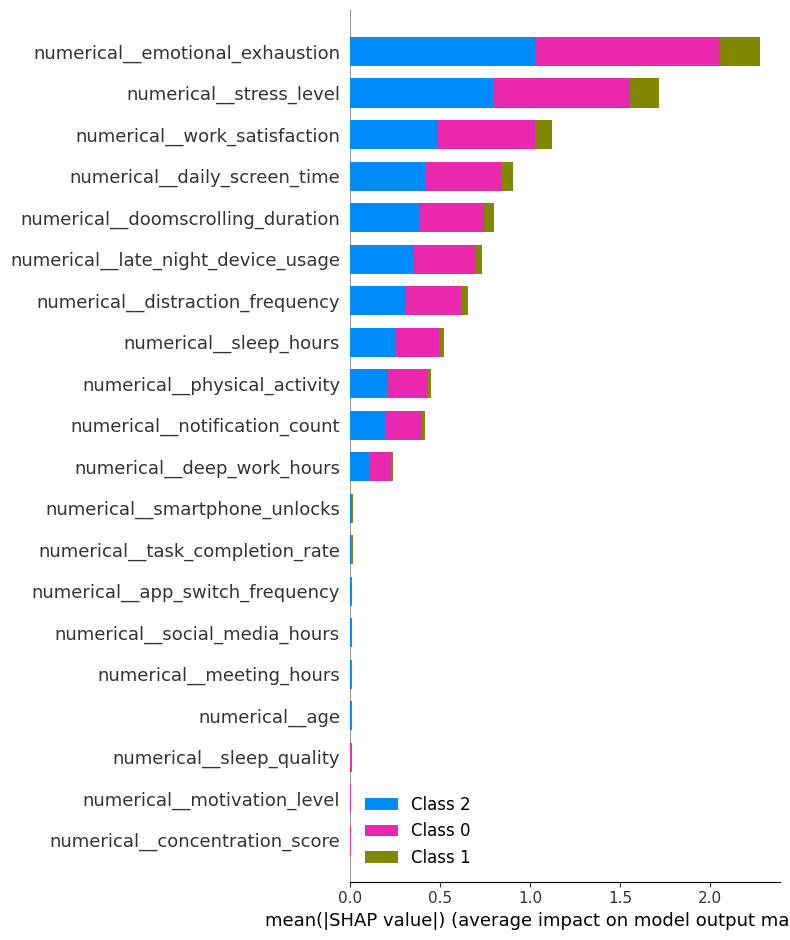

In [13]:
plt.figure(
    figsize=(12,8)
)

shap.summary_plot(

    shap_values,
    X_shap_processed,
    show=False

)

plt.tight_layout()

plt.savefig(

    interpretability_directory
    / "shap_summary_plot.png",
    dpi=300,
    bbox_inches="tight"

)

plt.show()

## 2.3 SHAP Bar Plot

Tóm tắt giá trị SHAP tuyệt đối trung bình của từng thuộc tính.
Khác với Biểu đồ tổng quan (Summary Plot), Biểu đồ thanh SHAP chỉ tập trung vào độ lớn tầm quan trọng của thuộc tính, giúp việc so sánh mức độ đóng góp tổng thể của các biến số khác nhau trở nên dễ dàng hơn.

In [14]:
# Tính Mean Absolute SHAP

mean_shap = np.abs(
    shap_values.values
).mean(
    axis=(0,2)
)

shap_importance = pd.DataFrame(

    {
        "Feature": X_shap_processed.columns,
        "Mean |SHAP|": mean_shap
    }

)

shap_importance = (

    shap_importance

    .sort_values(
        by="Mean |SHAP|",
        ascending=True
    )

)

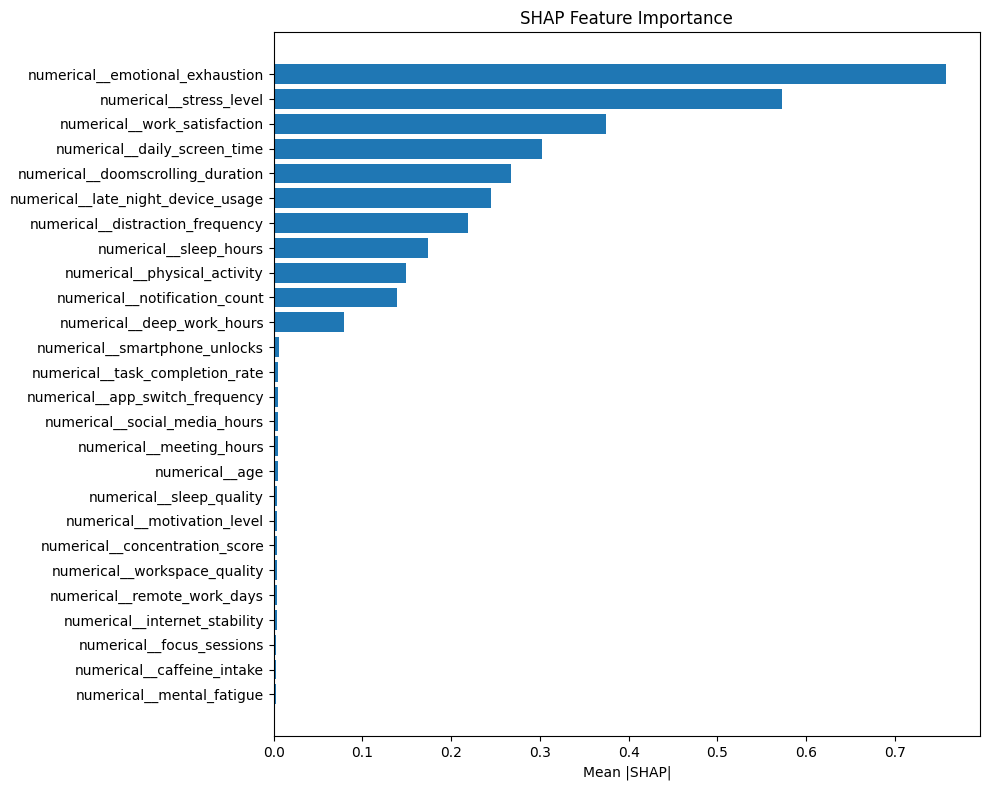

In [15]:
plt.figure(

    figsize=(10,8)

)

plt.barh(
    shap_importance["Feature"],
    shap_importance["Mean |SHAP|"]
)

plt.xlabel(
    "Mean |SHAP|"
)

plt.title(
    "SHAP Feature Importance"
)

plt.tight_layout()

plt.savefig(

    interpretability_directory
    / "shap_bar_plot.png",
    dpi=300,
    bbox_inches="tight"

)

plt.show()

## 2.4 Export SHAP Results

Xuất toàn bộ kết quả giải thích mô hình được tạo ra trong phần này nhằm phục vụ cho các nghiên cứu phân tích và trực quan hóa tiếp theo.

Các thành phần kết quả được xuất bao gồm:

- Độ quan trọng thuộc tính của XGBoost (XGBoost Feature Importance)
- Độ quan trọng thuộc tính theo SHAP (SHAP Feature Importance)
- Các giá trị SHAP (SHAP Values)
- Biểu đồ tổng quan SHAP (SHAP Summary Plot)
- Biểu đồ thanh SHAP (SHAP Bar Plot)

In [16]:
joblib.dump(

    shap_values,
    interpretability_directory
    / "shap_values.joblib"

)

['D:\\DA016\\models\\international_dataset\\interpretability\\shap_values.joblib']

In [17]:
mean_shap = np.abs(
    shap_values.values
).mean(
    axis=(0,2)
)

shap_importance = pd.DataFrame(

    {
        "Feature": X_shap_processed.columns,
        "Mean |SHAP|": mean_shap
    }

)

shap_importance = (

    shap_importance

    .sort_values(
        by="Mean |SHAP|",
        ascending=False
    )

    .reset_index(
        drop=True
    )

)

display(
    shap_importance.head(20)
)

shap_importance.to_csv(

    interpretability_directory
    / "shap_feature_importance.csv",
    index=False

)

,Feature,Mean |SHAP|
0,numerical__emotional_exhaustion,0.7581
1,numerical__stress_level,0.5724
2,numerical__work_satisfaction,0.3740
3,numerical__daily_screen_time,0.3022
4,numerical__doomscrolling_duration,0.2671
5,numerical__late_night_device_usage,0.2445
6,numerical__distraction_frequency,0.2188
7,numerical__sleep_hours,0.1739
8,numerical__physical_activity,0.1496
9,numerical__notification_count,0.1389


# 3. Local Interpretability

Trong khi khả năng giải thích toàn cục (Global Interpretability) làm rõ hành vi tổng thể của mô hình, khả năng giải thích cục bộ (Local Interpretability) lại tập trung vào việc lý giải một kết quả dự báo đơn lẻ.

Phần này nghiên cứu cách thức các thuộc tính riêng lẻ đóng góp vào kết quả dự báo về sự kiệt sức kỹ thuật số (Digital Burnout) của một sinh viên đại diện thông qua việc sử dụng Biểu đồ thác nước SHAP (SHAP Waterfall Plot).

In [18]:
# Dự đoán trên tập SHAP

prediction = xgboost_pipeline.predict(
    X_shap
)

prediction_probability = (
    xgboost_pipeline
    .predict_proba(
        X_shap
    )
)

In [19]:
instance_index = 0

print(
    f"Selected Sample: {instance_index}"
)

print(
    f"Actual Class: {y_validation.loc[X_shap.index[instance_index]]}"
)

print(
    f"Predicted Class: {prediction[instance_index]}"
)

Selected Sample: 0
Actual Class: 1
Predicted Class: 1


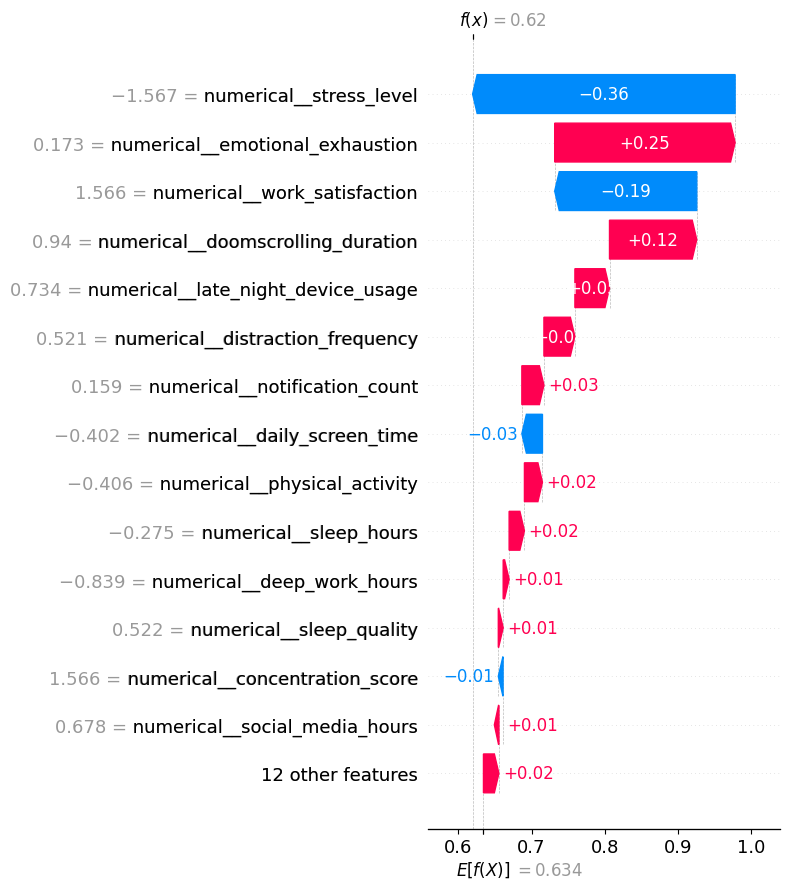

In [20]:
plt.figure(
    figsize=(10,8)
)

shap.plots.waterfall(

    shap_values[
        instance_index,
        :,
        prediction[instance_index]
    ],

    max_display=15,
    show=False

)

plt.tight_layout()

plt.savefig(

    interpretability_directory
    / "waterfall_plot.png",
    dpi=300,
    bbox_inches="tight"

)

plt.show()

In [21]:
probability = prediction_probability[
    instance_index
]

analysis = pd.DataFrame(

    {
        "Class":[
            "Low",
            "Moderate",
            "High"
        ],
        "Probability": probability
    }

)

display(
    analysis
)

,Class,Probability
0,Low,0.3714
1,Moderate,0.6068
2,High,0.0218


In [22]:
print(
    "Predicted Class:",
    prediction[instance_index]
)

Predicted Class: 1


In [23]:
analysis.to_csv(

    interpretability_directory
    / "individual_prediction.csv",
    index=False

)

# 4. Research Findings

Tóm tắt các phát hiện chính thu được từ phân tích giải thích mô hình.

Phần này tích hợp các kết quả từ Độ quan trọng thuộc tính của XGBoost, Khả năng giải thích toàn cục SHAP và Khả năng giải thích cục bộ nhằm làm rõ cách thức mô hình đã được huấn luyện nhận diện nguy cơ kiệt sức kỹ thuật số (Digital Burnout).

Các phát hiện này cung cấp bằng chứng thực nghiệm hỗ trợ cho tính minh bạch và độ tin cậy của mô hình dự báo nguy cơ kiệt sức kỹ thuật số được đề xuất.

In [24]:
# Top 10 SHAP Features

top_features = (
    shap_importance
    .head(10)
)

display(
    top_features
)

,Feature,Mean |SHAP|
0,numerical__emotional_exhaustion,0.7581
1,numerical__stress_level,0.5724
2,numerical__work_satisfaction,0.3740
3,numerical__daily_screen_time,0.3022
4,numerical__doomscrolling_duration,0.2671
5,numerical__late_night_device_usage,0.2445
6,numerical__distraction_frequency,0.2188
7,numerical__sleep_hours,0.1739
8,numerical__physical_activity,0.1496
9,numerical__notification_count,0.1389


In [25]:
feature_category_mapping = {

    "daily_screen_time": "Digital Exposure",
    "social_media_hours": "Digital Exposure",
    "doomscrolling_duration": "Digital Exposure",
    "notification_count": "Digital Exposure",
    "app_switch_frequency": "Digital Exposure",
    "mental_fatigue": "Burnout Symptoms",
    "stress_level": "Burnout Symptoms",
    "emotional_exhaustion": "Burnout Symptoms",
    "sleep_hours": "Sleep & Recovery",
    "sleep_quality": "Sleep & Recovery",
    "concentration_score": "Cognitive Performance",
    "focus_sessions": "Cognitive Performance",
    "deep_work_hours": "Cognitive Performance",
    "motivation_level": "Cognitive Performance"

}

In [26]:
research_summary = pd.DataFrame(

    {

        "Finding":[
            "Most Important Feature",
            "Number of Features",
            "Validation Samples",
            "SHAP Samples"
        ],

        "Value":[
            shap_importance.iloc[0]["Feature"],
            len(shap_importance),
            len(X_validation),
            len(X_shap)
        ]

    }

)

display(
    research_summary
)

,Finding,Value
0,Most Important Feature,numerical__emotional_exhaustion
1,Number of Features,26
2,Validation Samples,750000
3,SHAP Samples,1000


In [27]:
research_summary.to_csv(

    interpretability_directory
    / "research_summary.csv",
    index=False

)

# 5. Export Results

Xuất toàn bộ các thành phần kết quả giải thích mô hình được tạo ra trong suốt notebook này.

In [28]:
print(
    "Exported Files"
)

for file in sorted(
    interpretability_directory.glob("*")
):

    print(
        f"Đã xuất: {file.name}"
    )

Exported Files
Đã xuất: feature_importance.csv
Đã xuất: individual_prediction.csv
Đã xuất: research_summary.csv
Đã xuất: shap_bar_plot.png
Đã xuất: shap_feature_importance.csv
Đã xuất: shap_summary_plot.png
Đã xuất: shap_values.joblib
Đã xuất: waterfall_plot.png
